# Automatic Parking Playback

Load a Python-native checkpoint, simulate one episode for the best genome, and render polygon animation.

In [1]:
from pathlib import Path

from self_parking.evolution.config import ScenarioConfig, SimulationConfig
from self_parking.io.checkpoint import CheckpointStore
from self_parking.simulation.engine import simulate_episode
from self_parking.viz.animation import animate_episode


In [2]:
checkpoint_path = Path('../artifacts/checkpoints/notebook-training.json')
ckpt = CheckpointStore.load(checkpoint_path)
simulation_config = SimulationConfig(**ckpt.simulation_config)
scenario_data = dict(ckpt.scenario_config)
scenario_data['static_skip_cells'] = tuple(tuple(v) for v in scenario_data['static_skip_cells'])
scenario_config = ScenarioConfig(**scenario_data)
episode = simulate_episode(
    genome=ckpt.best_genome,
    simulation_config=simulation_config,
    scenario_config=scenario_config,
    seed=int(ckpt.metadata['seed']),
)
episode.loss


1.625577697549545

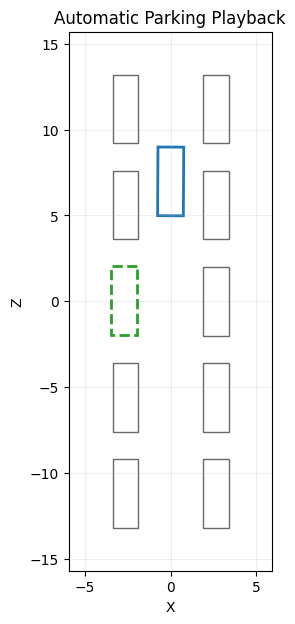

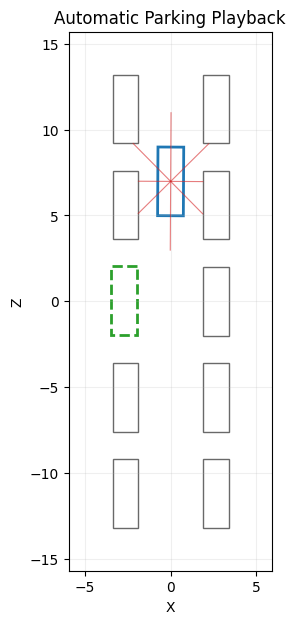

In [3]:
fig, ani = animate_episode(episode, scenario_config=scenario_config, show_sensors=True)
fig


PosixPath('../artifacts/playback/notebook-playback.gif')

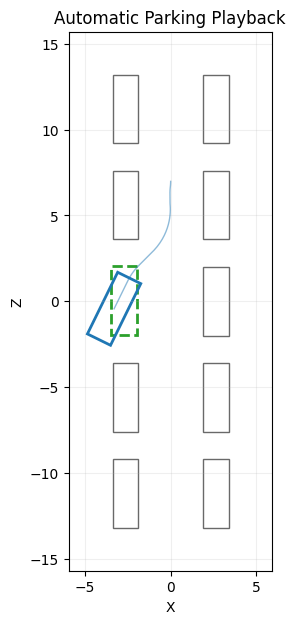

In [4]:
output = Path('../artifacts/playback/notebook-playback.gif')
animate_episode(episode, scenario_config=scenario_config, save_path=output, show_sensors=False)
output
